Loaded Allen-Cahn reference from allen_cahn_python.mat
Allen-Cahn data: t (201,) x (513,) usol (201, 513)
Domain: x=[-1.0, 1.0], t=[0.0, 1.0]
PDE: u_t - 0.001 u_xx + 5 u^3 - 5 u = 0
Traditional ALM-PINN with L-BFGS inner solve:
  fixed points
  no jitter
  no resampling
  theta inner optimizer: scipy L-BFGS-B
  lambda update: lambda <- lambda + rho*c
  rho update: blockwise if feasibility stalls
BC_MODE = periodic_value_and_derivative
USE_PDE_ANCHORS = True
SCALE_RESIDUAL_BY_A = True
n_params = 1981
constraints: pde 900 bcv 100 bcd 100 ic 200 total 1300
objective points = 6400
network = [2, 30, 30, 30, 1]
W_PDE_OBJ = 10.0
TOTAL_LBFGS_BUDGET = 50000
MAX_OUTER = 100 INNER_MAXITER = 500
rho0: pde 1.0 bcv 1.0 bcd 1.0 ic 10.0
rho_growth = 1.5 rho_max = 100.0

[OUTER 1/100] rho_pde=1.000e+00, rho_bcv=1.000e+00, rho_bcd=1.000e+00, rho_ic=1.000e+01
[ALM] outer=001 loss=6.035e-03 obj_scaled=2.308e-03 raw_pde_mse=5.771e-03 pde=(1.506e-02,6.246e-02) bcv=(9.010e-03,2.256e-02) bcd=(1.354e-02,9.102e

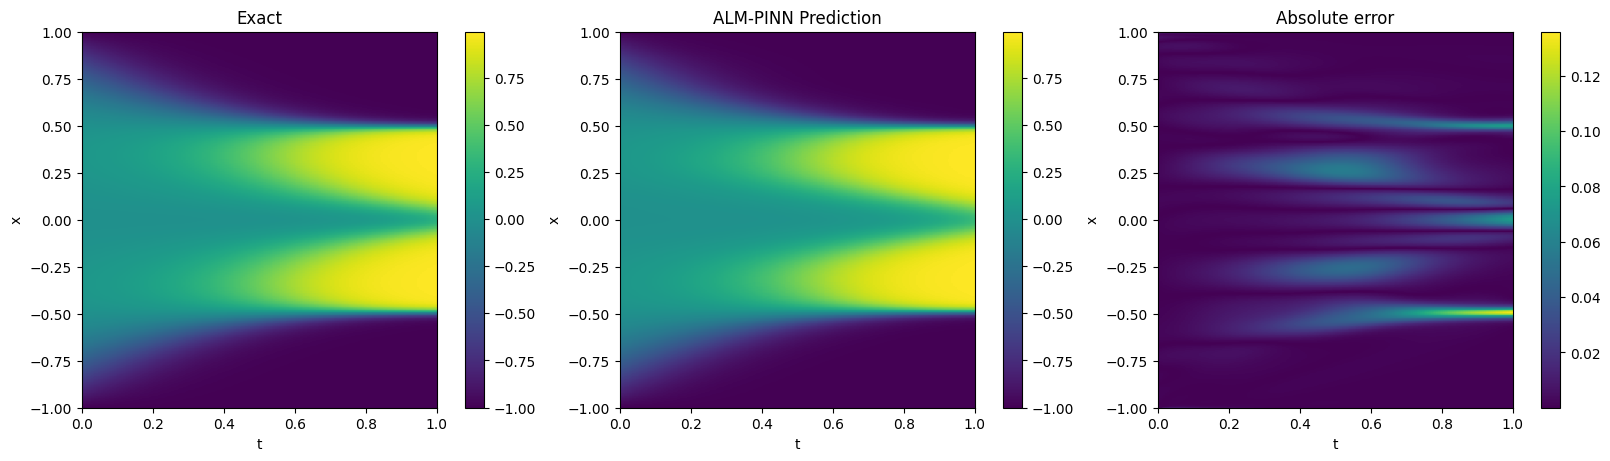

: 

In [ ]:

# ============================================================
# Traditional ALM-PINN for 1D Allen-Cahn Equation
# JAX + SciPy L-BFGS-B
#
# PDE:
#     u_t - eps*u_xx + a*u^3 - a*u = 0,
#     (x,t) in [-1,1] x [0,1]
#
# IC:
#     u(x,0) = x^2 cos(pi*x)
#
# Periodic BC:
#     u(-1,t)   = u(1,t)
#     u_x(-1,t) = u_x(1,t)
#
# This is traditional deterministic ALM:
#   - fixed PDE objective points
#   - fixed PDE/BC/IC constraint points
#   - no jitter
#   - no resampling
#   - full-batch SciPy L-BFGS-B inner solve
#
# ALM:
#     theta^{k+1} approximately minimizes
#         obj(theta) + lambda^T c(theta) + 0.5*rho*||c(theta)||^2
#     lambda <- lambda + rho*c(theta)
#
# This matches your Allen-Cahn SQP setup:
#   - eps = 1e-3
#   - a = 5
#   - data file: allen_cahn_python.mat
#   - network [2, 30, 30, 30, 1]
#   - PDE objective points: 80 x 80
#   - PDE constraints: 30 x 30
#   - BC value constraints: 100
#   - BC derivative constraints: 100
#   - IC constraints: 200
#   - input normalization ON
#   - residual scaling: r / max(1,a), same as your current SQP file
# ============================================================

import os
import time
import math
from functools import partial
from pathlib import Path

import numpy as np
import scipy.io
import scipy.optimize
import matplotlib.pyplot as plt

# -----------------------------
# Device
# -----------------------------
USE_CPU = False
CUDA_DEVICE = "0"

if USE_CPU:
    os.environ["JAX_PLATFORMS"] = "cpu"
else:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", CUDA_DEVICE)

os.environ.setdefault("XLA_FLAGS", "--xla_gpu_autotune_level=0")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_matmul_precision", "highest")

import jax.numpy as jnp
from jax import random, grad, vmap, hessian


# ============================================================
# Precision
# ============================================================
DTYPE = jnp.float64
EPS = DTYPE(1e-12)


# ============================================================
# Problem setup
# ============================================================
X_MIN = -1.0
X_MAX = 1.0
T_MIN = 0.0
T_MAX = 1.0

EPS_AC = 1.0e-3
A_AC = 5.0

# Match current SQP code: r_scaled = r / max(1,a).
# Set False if you want raw residual optimization.
SCALE_RESIDUAL_BY_A = True

MAT_PATHS = [
    "allen_cahn_python.mat",
    "data/allen_cahn_python.mat",
    "allen_cahn.mat",
    "data/allen_cahn.mat",
]


# ============================================================
# Point counts: match your SQP Allen-Cahn setup
# ============================================================
NX_PDE_OBJ = 80
NT_PDE_OBJ = 80
K_PDE_OBJ = NX_PDE_OBJ * NT_PDE_OBJ

NX_PDE_CON = 30
NT_PDE_CON = 30
K_PDE_CON = NX_PDE_CON * NT_PDE_CON

K_BC = 100
K_IC = 200

USE_PDE_ANCHORS = True

# PDE + periodic value BC + periodic derivative BC + IC
M_CON = K_PDE_CON + 2 * K_BC + K_IC


# ============================================================
# Network
# ============================================================
HIDDEN_DIM = 30
NUM_HIDDEN = 3


# ============================================================
# ALM / L-BFGS settings
# ============================================================
W_PDE_OBJ = 10.0

TOTAL_LBFGS_BUDGET = 50000
INNER_MAXITER = 500
MAX_OUTER = int(math.ceil(TOTAL_LBFGS_BUDGET / INNER_MAXITER))

LBFGS_FTOL = 1e-12
LBFGS_GTOL = 1e-8
LBFGS_MAXLS = 50
LBFGS_MAXCOR = 50

# Initial rho values.
RHO_PDE0 = 1.0
RHO_BCV0 = 1.0
RHO_BCD0 = 1.0
RHO_IC0 = 10.0

# Capped rho schedule. This avoids the old rho=1e4 over-penalization.
RHO_GROWTH = 1.5
RHO_MAX = 1e2
IMPROVE_THRESHOLD = 0.9

SEED = 0
SAVE_PREFIX = "traditional_alm_allen_cahn"
SAVE_BEST = f"{SAVE_PREFIX}_best.npy"
SAVE_FINAL = f"{SAVE_PREFIX}_final.npy"


# ============================================================
# Load data
# ============================================================
def load_allen_cahn_mat(paths=MAT_PATHS):
    chosen = None
    for p in paths:
        if Path(p).exists():
            chosen = p
            break

    if chosen is None:
        raise FileNotFoundError(
            "Could not find Allen-Cahn reference data. Checked:\n"
            + "\n".join(paths)
        )

    d = scipy.io.loadmat(chosen)

    t = np.asarray(d["t"]).squeeze().astype(np.float64)
    x = np.asarray(d["x"]).squeeze().astype(np.float64)
    usol = np.asarray(d["usol"], dtype=np.float64)

    if usol.shape == (x.size, t.size):
        usol = usol.T

    if usol.shape != (t.size, x.size):
        raise ValueError(
            f"Unexpected usol shape {usol.shape}; expected {(t.size, x.size)}"
        )

    eps = float(np.asarray(d["eps"]).squeeze()) if "eps" in d else EPS_AC
    a = float(np.asarray(d["a"]).squeeze()) if "a" in d else A_AC

    return t, x, usol, eps, a, chosen


def make_grid_points(x_np, t_np):
    TT, XX = np.meshgrid(t_np, x_np, indexing="ij")
    X_grid = np.stack([XX.reshape(-1), TT.reshape(-1)], axis=1)
    return X_grid, TT.shape


# ============================================================
# Network helpers
# ============================================================
def init_mlp_params(key, layer_sizes):
    params = []
    keys = random.split(key, len(layer_sizes) - 1)

    for k, (m, n) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        W = random.normal(k, (m, n), dtype=DTYPE) * jnp.sqrt(DTYPE(2.0) / DTYPE(m))
        b = jnp.zeros((n,), dtype=DTYPE)
        params.append({"W": W, "b": b})

    return params


def normalize_xt(X):
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = DTYPE(2.0) * (x - DTYPE(X_MIN)) / (DTYPE(X_MAX) - DTYPE(X_MIN)) - DTYPE(1.0)
    t_n = DTYPE(2.0) * (t - DTYPE(T_MIN)) / (DTYPE(T_MAX) - DTYPE(T_MIN)) - DTYPE(1.0)

    return jnp.concatenate([x_n, t_n], axis=1)


def mlp_apply(params, X):
    h = normalize_xt(X)

    for i, layer in enumerate(params):
        h = h @ layer["W"] + layer["b"]
        if i < len(params) - 1:
            h = jnp.tanh(h)

    return h


def flatten_params(params):
    flat_parts = []
    shapes = []

    for layer in params:
        W, b = layer["W"], layer["b"]
        flat_parts.append(W.reshape(-1))
        flat_parts.append(b.reshape(-1))
        shapes.append((W.shape, b.shape))

    return jnp.concatenate(flat_parts).astype(DTYPE), tuple(shapes)


def unflatten_params(theta, shapes):
    params = []
    idx = 0

    for W_shape, b_shape in shapes:
        W_size = math.prod(W_shape)
        b_size = math.prod(b_shape)

        W = theta[idx:idx + W_size].reshape(W_shape)
        idx += W_size

        b = theta[idx:idx + b_size].reshape(b_shape)
        idx += b_size

        params.append({"W": W, "b": b})

    if idx != theta.size:
        raise ValueError(f"Used {idx} parameters but theta has size {theta.size}")

    return params


# ============================================================
# Fixed point sets
# ============================================================
def sample_pde_obj_fixed(key, x_min, x_max, t_min, t_max):
    dx = (DTYPE(x_max) - DTYPE(x_min)) / DTYPE(NX_PDE_OBJ)
    dt = (DTYPE(t_max) - DTYPE(t_min)) / DTYPE(NT_PDE_OBJ)

    it, ix = jnp.meshgrid(
        jnp.arange(NT_PDE_OBJ),
        jnp.arange(NX_PDE_OBJ),
        indexing="ij",
    )
    it = it.reshape(-1).astype(jnp.int32)
    ix = ix.reshape(-1).astype(jnp.int32)

    x0 = DTYPE(x_min) + DTYPE(ix) * dx
    t0 = DTYPE(t_min) + DTYPE(it) * dt

    u = random.uniform(key, (K_PDE_OBJ, 2), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = x0 + u[:, 0] * dx
    ts = t0 + u[:, 1] * dt

    return jnp.stack([xs, ts], axis=1)


def sample_pde_con_fixed(key, x_min, x_max, t_min, t_max):
    dx = (DTYPE(x_max) - DTYPE(x_min)) / DTYPE(NX_PDE_CON)
    dt = (DTYPE(t_max) - DTYPE(t_min)) / DTYPE(NT_PDE_CON)

    it, ix = jnp.meshgrid(
        jnp.arange(NT_PDE_CON),
        jnp.arange(NX_PDE_CON),
        indexing="ij",
    )
    it = it.reshape(-1).astype(jnp.int32)
    ix = ix.reshape(-1).astype(jnp.int32)

    x0 = DTYPE(x_min) + DTYPE(ix) * dx
    t0 = DTYPE(t_min) + DTYPE(it) * dt

    u = random.uniform(key, (K_PDE_CON, 2), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = x0 + u[:, 0] * dx
    ts = t0 + u[:, 1] * dt

    return jnp.stack([xs, ts], axis=1)


def sample_bc_fixed(key, x_min, x_max, t_min, t_max):
    # Periodic pair with matched times.
    dt = (DTYPE(t_max) - DTYPE(t_min)) / DTYPE(K_BC)

    j = jnp.arange(K_BC, dtype=jnp.int32)
    t0 = DTYPE(t_min) + DTYPE(j) * dt

    u = random.uniform(key, (K_BC,), minval=0.0, maxval=1.0, dtype=DTYPE)
    ts = (t0 + u * dt).reshape(-1, 1)

    XL = jnp.concatenate([DTYPE(x_min) * jnp.ones_like(ts), ts], axis=1)
    XR = jnp.concatenate([DTYPE(x_max) * jnp.ones_like(ts), ts], axis=1)

    return XL, XR


def allen_cahn_ic_target(x):
    return x ** 2 * jnp.cos(jnp.pi * x)


def sample_ic_fixed(key, x_min, x_max, t0):
    dx = (DTYPE(x_max) - DTYPE(x_min)) / DTYPE(K_IC)

    j = jnp.arange(K_IC, dtype=jnp.int32)
    x0 = DTYPE(x_min) + DTYPE(j) * dx

    u = random.uniform(key, (K_IC,), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = (x0 + u * dx).reshape(-1, 1)

    ts = DTYPE(t0) * jnp.ones_like(xs)
    Xic = jnp.concatenate([xs, ts], axis=1)

    u0 = allen_cahn_ic_target(xs[:, 0])

    return Xic, u0


# ============================================================
# PDE residual and BC derivatives
# ============================================================
def pde_residual_raw(params, X, eps_ac, a_ac):
    """
    Raw Allen-Cahn residual:
        r = u_t - eps*u_xx + a*u^3 - a*u
    """
    def u_fun(xt):
        return mlp_apply(params, xt[None, :])[0, 0]

    u = vmap(u_fun)(X)
    du = vmap(grad(u_fun))(X)
    H = vmap(hessian(u_fun))(X)

    u_t = du[:, 1]
    u_xx = H[:, 0, 0]

    return u_t - DTYPE(eps_ac) * u_xx + DTYPE(a_ac) * u ** 3 - DTYPE(a_ac) * u


def pde_residual(params, X, eps_ac, a_ac):
    r = pde_residual_raw(params, X, eps_ac, a_ac)
    if SCALE_RESIDUAL_BY_A:
        return r / jnp.maximum(DTYPE(1.0), DTYPE(a_ac))
    return r


def u_and_ux(params, X):
    def u_fun(xt):
        return mlp_apply(params, xt[None, :])[0, 0]

    u = vmap(u_fun)(X)
    du = vmap(grad(u_fun))(X)
    ux = du[:, 0]
    return u, ux


# ============================================================
# Objective and constraints
# ============================================================
@partial(jax.jit, static_argnames=("shapes",))
def pde_objective(theta, shapes, X_obj, eps_ac, a_ac, w_pde_obj):
    params = unflatten_params(theta, shapes)
    r = pde_residual(params, X_obj, eps_ac, a_ac)
    return DTYPE(w_pde_obj) * jnp.mean(r ** 2)


@partial(jax.jit, static_argnames=("shapes",))
def pde_objective_raw_mse(theta, shapes, X_obj, eps_ac, a_ac):
    params = unflatten_params(theta, shapes)
    r = pde_residual_raw(params, X_obj, eps_ac, a_ac)
    return jnp.mean(r ** 2)


@partial(jax.jit, static_argnames=("shapes", "use_pde_anchors"))
def constraint_blocks(theta, shapes,
                      X_pde_con, X_bc_L, X_bc_R, X_ic, u0_ic,
                      eps_ac, a_ac,
                      use_pde_anchors: bool):
    params = unflatten_params(theta, shapes)

    if use_pde_anchors:
        c_pde = pde_residual(params, X_pde_con, eps_ac, a_ac)
    else:
        c_pde = jnp.zeros((0,), dtype=DTYPE)

    # Periodic value BC.
    uL, uxL = u_and_ux(params, X_bc_L)
    uR, uxR = u_and_ux(params, X_bc_R)

    c_bcv = uL - uR

    # Periodic derivative BC.
    c_bcd = uxL - uxR

    # IC.
    u_ic = mlp_apply(params, X_ic)[:, 0]
    c_ic = u_ic - u0_ic

    return c_pde, c_bcv, c_bcd, c_ic


@partial(jax.jit, static_argnames=("shapes", "use_pde_anchors"))
def alm_loss_and_grad(theta, shapes,
                      lam_pde, lam_bcv, lam_bcd, lam_ic,
                      rho_pde, rho_bcv, rho_bcd, rho_ic,
                      X_obj, X_pde_con, X_bc_L, X_bc_R, X_ic, u0_ic,
                      eps_ac, a_ac, w_pde_obj,
                      use_pde_anchors: bool):
    def loss_fn(th):
        obj = pde_objective(th, shapes, X_obj, eps_ac, a_ac, w_pde_obj)

        c_pde, c_bcv, c_bcd, c_ic = constraint_blocks(
            th, shapes,
            X_pde_con, X_bc_L, X_bc_R, X_ic, u0_ic,
            eps_ac, a_ac,
            use_pde_anchors,
        )

        if use_pde_anchors:
            alm_pde = (
                jnp.mean(lam_pde * c_pde)
                + DTYPE(0.5) * DTYPE(rho_pde) * jnp.mean(c_pde ** 2)
            )
            pde_rms = jnp.sqrt(jnp.mean(c_pde ** 2) + EPS)
            pde_max = jnp.max(jnp.abs(c_pde))
        else:
            alm_pde = DTYPE(0.0)
            pde_rms = DTYPE(0.0)
            pde_max = DTYPE(0.0)

        alm_bcv = (
            jnp.mean(lam_bcv * c_bcv)
            + DTYPE(0.5) * DTYPE(rho_bcv) * jnp.mean(c_bcv ** 2)
        )

        alm_bcd = (
            jnp.mean(lam_bcd * c_bcd)
            + DTYPE(0.5) * DTYPE(rho_bcd) * jnp.mean(c_bcd ** 2)
        )

        alm_ic = (
            jnp.mean(lam_ic * c_ic)
            + DTYPE(0.5) * DTYPE(rho_ic) * jnp.mean(c_ic ** 2)
        )

        loss = obj + alm_pde + alm_bcv + alm_bcd + alm_ic

        aux = {
            "obj": obj,
            "alm_pde": alm_pde,
            "alm_bcv": alm_bcv,
            "alm_bcd": alm_bcd,
            "alm_ic": alm_ic,
            "pde_rms": pde_rms,
            "bcv_rms": jnp.sqrt(jnp.mean(c_bcv ** 2) + EPS),
            "bcd_rms": jnp.sqrt(jnp.mean(c_bcd ** 2) + EPS),
            "ic_rms": jnp.sqrt(jnp.mean(c_ic ** 2) + EPS),
            "pde_max": pde_max,
            "bcv_max": jnp.max(jnp.abs(c_bcv)),
            "bcd_max": jnp.max(jnp.abs(c_bcd)),
            "ic_max": jnp.max(jnp.abs(c_ic)),
        }

        return loss, aux

    (loss, aux), g = jax.value_and_grad(loss_fn, has_aux=True)(theta)
    return loss, g, aux


# ============================================================
# Evaluation
# ============================================================
@partial(jax.jit, static_argnames=("shapes",))
def predict_u(theta, shapes, X):
    params = unflatten_params(theta, shapes)
    return mlp_apply(params, X)[:, 0]


def eval_full_grid(theta, shapes, x_np, t_np, usol_np):
    X_grid_np, grid_shape = make_grid_points(x_np, t_np)
    X_grid = jnp.asarray(X_grid_np, dtype=DTYPE)

    u_pred = np.asarray(predict_u(theta, shapes, X_grid)).reshape(grid_shape)
    u_true = np.asarray(usol_np, dtype=np.float64)

    mse = float(np.mean((u_pred - u_true) ** 2))
    rel_l2 = float(np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + 1e-12))

    return mse, rel_l2, u_pred


def block_stats(arr):
    arr = np.asarray(arr)
    if arr.size == 0:
        return 0.0, 0.0
    return float(np.sqrt(np.mean(arr ** 2) + 1e-30)), float(np.max(np.abs(arr)))


def save_heatmaps(x_np, t_np, u_true, u_pred, prefix=SAVE_PREFIX):
    err = np.abs(u_pred - u_true)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

    vmin = min(float(np.min(u_true)), float(np.min(u_pred)))
    vmax = max(float(np.max(u_true)), float(np.max(u_pred)))

    panels = [
        (u_true, "Exact", vmin, vmax),
        (u_pred, "ALM-PINN Prediction", vmin, vmax),
        (err, "Absolute error", None, None),
    ]

    for ax, (arr, title, lo, hi) in zip(axes, panels):
        kwargs = {}
        if lo is not None and hi is not None:
            kwargs["vmin"] = lo
            kwargs["vmax"] = hi

        im = ax.imshow(
            arr.T,
            origin="lower",
            aspect="auto",
            extent=[t_np[0], t_np[-1], x_np[0], x_np[-1]],
            interpolation="nearest",
            **kwargs,
        )
        ax.set_xlabel("t")
        ax.set_ylabel("x")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)

    out_png = f"{prefix}_heatmaps.png"
    out_pdf = f"{prefix}_heatmaps.pdf"

    plt.savefig(out_png, dpi=300)
    plt.savefig(out_pdf)

    print("Saved:", out_png)
    print("Saved:", out_pdf)
    plt.show()


# ============================================================
# SciPy L-BFGS inner solve
# ============================================================
def lbfgs_inner_solve(theta, shapes,
                      lam_pde, lam_bcv, lam_bcd, lam_ic,
                      rho_pde, rho_bcv, rho_bcd, rho_ic,
                      X_obj, X_pde_con, X_bc_L, X_bc_R, X_ic, u0_ic,
                      eps_ac, a_ac, w_pde_obj,
                      use_pde_anchors,
                      maxiter):
    def fun_and_jac(theta_np):
        th = jnp.asarray(theta_np, dtype=DTYPE)

        loss, g, _ = alm_loss_and_grad(
            th, shapes,
            lam_pde, lam_bcv, lam_bcd, lam_ic,
            DTYPE(rho_pde), DTYPE(rho_bcv), DTYPE(rho_bcd), DTYPE(rho_ic),
            X_obj, X_pde_con, X_bc_L, X_bc_R, X_ic, u0_ic,
            DTYPE(eps_ac), DTYPE(a_ac), DTYPE(w_pde_obj),
            use_pde_anchors,
        )

        return float(loss), np.asarray(g, dtype=np.float64)

    theta0_np = np.asarray(theta, dtype=np.float64)

    res = scipy.optimize.minimize(
        fun_and_jac,
        theta0_np,
        method="L-BFGS-B",
        jac=True,
        options={
            "maxiter": int(maxiter),
            "ftol": LBFGS_FTOL,
            "gtol": LBFGS_GTOL,
            "maxls": LBFGS_MAXLS,
            "maxcor": LBFGS_MAXCOR,
            "disp": False,
        },
    )

    return jnp.asarray(res.x, dtype=DTYPE), res


# ============================================================
# Training
# ============================================================
def train_traditional_alm_allen_cahn():
    t_np, x_np, usol_np, eps_file, a_file, data_path = load_allen_cahn_mat()

    eps_ac = float(EPS_AC)
    a_ac = float(A_AC)

    if abs(eps_file - eps_ac) > 1e-14:
        print(f"WARNING: file eps={eps_file}, code EPS_AC={eps_ac}. Using code EPS_AC={eps_ac}.")

    if abs(a_file - a_ac) > 1e-14:
        print(f"WARNING: file a={a_file}, code A_AC={a_ac}. Using code A_AC={a_ac}.")

    x_min, x_max = float(x_np.min()), float(x_np.max())
    t_min, t_max = float(t_np.min()), float(t_np.max())

    key = random.PRNGKey(SEED)
    key, k_params, k_obj, k_pde, k_bc, k_ic = random.split(key, 6)

    layer_sizes = [2] + [HIDDEN_DIM] * NUM_HIDDEN + [1]
    params0 = init_mlp_params(k_params, layer_sizes)
    theta, shapes = flatten_params(params0)

    X_obj = sample_pde_obj_fixed(k_obj, x_min, x_max, t_min, t_max)
    X_pde_con = sample_pde_con_fixed(k_pde, x_min, x_max, t_min, t_max)
    X_bc_L, X_bc_R = sample_bc_fixed(k_bc, x_min, x_max, t_min, t_max)
    X_ic, u0_ic = sample_ic_fixed(k_ic, x_min, x_max, t_min)

    n_pde = K_PDE_CON if USE_PDE_ANCHORS else 0
    n_bcv = K_BC
    n_bcd = K_BC
    n_ic = K_IC
    m_con = n_pde + n_bcv + n_bcd + n_ic

    lam_pde = jnp.zeros((n_pde,), dtype=DTYPE)
    lam_bcv = jnp.zeros((n_bcv,), dtype=DTYPE)
    lam_bcd = jnp.zeros((n_bcd,), dtype=DTYPE)
    lam_ic = jnp.zeros((n_ic,), dtype=DTYPE)

    rho_pde = float(RHO_PDE0)
    rho_bcv = float(RHO_BCV0)
    rho_bcd = float(RHO_BCD0)
    rho_ic = float(RHO_IC0)

    prev_pde_rms = None
    prev_bcv_rms = None
    prev_bcd_rms = None
    prev_ic_rms = None

    best_rel = float("inf")
    best_mse = float("inf")
    best_theta = theta
    best_outer = 0

    print("Loaded Allen-Cahn reference from", data_path)
    print("Allen-Cahn data:", "t", t_np.shape, "x", x_np.shape, "usol", usol_np.shape)
    print(f"Domain: x=[{x_min}, {x_max}], t=[{t_min}, {t_max}]")
    print(f"PDE: u_t - {eps_ac:g} u_xx + {a_ac:g} u^3 - {a_ac:g} u = 0")
    print("Traditional ALM-PINN with L-BFGS inner solve:")
    print("  fixed points")
    print("  no jitter")
    print("  no resampling")
    print("  theta inner optimizer: scipy L-BFGS-B")
    print("  lambda update: lambda <- lambda + rho*c")
    print("  rho update: blockwise if feasibility stalls")
    print("BC_MODE = periodic_value_and_derivative")
    print("USE_PDE_ANCHORS =", USE_PDE_ANCHORS)
    print("SCALE_RESIDUAL_BY_A =", SCALE_RESIDUAL_BY_A)
    print("n_params =", int(theta.size))
    print("constraints: pde", n_pde, "bcv", n_bcv, "bcd", n_bcd, "ic", n_ic, "total", m_con)
    print("objective points =", K_PDE_OBJ)
    print("network =", layer_sizes)
    print("W_PDE_OBJ =", W_PDE_OBJ)
    print("TOTAL_LBFGS_BUDGET =", TOTAL_LBFGS_BUDGET)
    print("MAX_OUTER =", MAX_OUTER, "INNER_MAXITER =", INNER_MAXITER)
    print("rho0: pde", rho_pde, "bcv", rho_bcv, "bcd", rho_bcd, "ic", rho_ic)
    print("rho_growth =", RHO_GROWTH, "rho_max =", RHO_MAX)

    t0_wall = time.time()

    # Warm-up compile.
    _ = alm_loss_and_grad(
        theta, shapes,
        lam_pde, lam_bcv, lam_bcd, lam_ic,
        DTYPE(rho_pde), DTYPE(rho_bcv), DTYPE(rho_bcd), DTYPE(rho_ic),
        X_obj, X_pde_con, X_bc_L, X_bc_R, X_ic, u0_ic,
        DTYPE(eps_ac), DTYPE(a_ac), DTYPE(W_PDE_OBJ),
        USE_PDE_ANCHORS,
    )

    for outer in range(1, MAX_OUTER + 1):
        print(
            f"\n[OUTER {outer}/{MAX_OUTER}] "
            f"rho_pde={rho_pde:.3e}, rho_bcv={rho_bcv:.3e}, "
            f"rho_bcd={rho_bcd:.3e}, rho_ic={rho_ic:.3e}"
        )

        theta, res = lbfgs_inner_solve(
            theta, shapes,
            lam_pde, lam_bcv, lam_bcd, lam_ic,
            rho_pde, rho_bcv, rho_bcd, rho_ic,
            X_obj, X_pde_con, X_bc_L, X_bc_R, X_ic, u0_ic,
            DTYPE(eps_ac), DTYPE(a_ac), DTYPE(W_PDE_OBJ),
            USE_PDE_ANCHORS,
            maxiter=INNER_MAXITER,
        )

        loss, _, aux = alm_loss_and_grad(
            theta, shapes,
            lam_pde, lam_bcv, lam_bcd, lam_ic,
            DTYPE(rho_pde), DTYPE(rho_bcv), DTYPE(rho_bcd), DTYPE(rho_ic),
            X_obj, X_pde_con, X_bc_L, X_bc_R, X_ic, u0_ic,
            DTYPE(eps_ac), DTYPE(a_ac), DTYPE(W_PDE_OBJ),
            USE_PDE_ANCHORS,
        )

        c_pde, c_bcv, c_bcd, c_ic = constraint_blocks(
            theta, shapes,
            X_pde_con, X_bc_L, X_bc_R, X_ic, u0_ic,
            DTYPE(eps_ac), DTYPE(a_ac),
            USE_PDE_ANCHORS,
        )

        pde_rms, pde_max = block_stats(np.asarray(c_pde))
        bcv_rms, bcv_max = block_stats(np.asarray(c_bcv))
        bcd_rms, bcd_max = block_stats(np.asarray(c_bcd))
        ic_rms, ic_max = block_stats(np.asarray(c_ic))

        raw_pde_mse = float(
            pde_objective_raw_mse(
                theta, shapes, X_obj, DTYPE(eps_ac), DTYPE(a_ac)
            )
        )

        # Classical multiplier update.
        if USE_PDE_ANCHORS:
            lam_pde = lam_pde + DTYPE(rho_pde) * c_pde

        lam_bcv = lam_bcv + DTYPE(rho_bcv) * c_bcv
        lam_bcd = lam_bcd + DTYPE(rho_bcd) * c_bcd
        lam_ic = lam_ic + DTYPE(rho_ic) * c_ic

        # Blockwise rho update.
        if USE_PDE_ANCHORS and prev_pde_rms is not None and pde_rms > IMPROVE_THRESHOLD * prev_pde_rms:
            rho_pde = min(RHO_GROWTH * rho_pde, RHO_MAX)

        if prev_bcv_rms is not None and bcv_rms > IMPROVE_THRESHOLD * prev_bcv_rms:
            rho_bcv = min(RHO_GROWTH * rho_bcv, RHO_MAX)

        if prev_bcd_rms is not None and bcd_rms > IMPROVE_THRESHOLD * prev_bcd_rms:
            rho_bcd = min(RHO_GROWTH * rho_bcd, RHO_MAX)

        if prev_ic_rms is not None and ic_rms > IMPROVE_THRESHOLD * prev_ic_rms:
            rho_ic = min(RHO_GROWTH * rho_ic, RHO_MAX)

        prev_pde_rms = pde_rms
        prev_bcv_rms = bcv_rms
        prev_bcd_rms = bcd_rms
        prev_ic_rms = ic_rms

        mse, rel_l2, _ = eval_full_grid(theta, shapes, x_np, t_np, usol_np)

        if rel_l2 < best_rel:
            best_rel = rel_l2
            best_mse = mse
            best_theta = theta
            best_outer = outer
            np.save(SAVE_BEST, np.asarray(best_theta, dtype=np.float64))
            improved = True
        else:
            improved = False

        lam_pde_rms = block_stats(np.asarray(lam_pde))[0]
        lam_bcv_rms = block_stats(np.asarray(lam_bcv))[0]
        lam_bcd_rms = block_stats(np.asarray(lam_bcd))[0]
        lam_ic_rms = block_stats(np.asarray(lam_ic))[0]

        print(
            f"[ALM] outer={outer:03d} "
            f"loss={float(loss):.3e} "
            f"obj_scaled={float(aux['obj']):.3e} "
            f"raw_pde_mse={raw_pde_mse:.3e} "
            f"pde=({pde_rms:.3e},{pde_max:.3e}) "
            f"bcv=({bcv_rms:.3e},{bcv_max:.3e}) "
            f"bcd=({bcd_rms:.3e},{bcd_max:.3e}) "
            f"ic=({ic_rms:.3e},{ic_max:.3e}) "
            f"relL2={rel_l2:.3e} "
            f"best={best_rel:.3e} "
            f"lbfgs_success={res.success} "
            f"nit={res.nit} "
            f"msg='{res.message}'"
        )

        print(
            f"      lam_rms: pde={lam_pde_rms:.3e}, "
            f"bcv={lam_bcv_rms:.3e}, bcd={lam_bcd_rms:.3e}, ic={lam_ic_rms:.3e}"
        )

        if improved:
            print(f"      >>> new best relL2={best_rel:.3e}; saved -> {SAVE_BEST}")

        if not np.isfinite(rel_l2) or not np.isfinite(float(loss)):
            print("Stopping early because non-finite value appeared.")
            break

    elapsed = time.time() - t0_wall

    np.save(SAVE_FINAL, np.asarray(theta, dtype=np.float64))

    print("\n[done] elapsed = {:.2f}s".format(elapsed))
    print(f"[FINAL] full-grid MSE={mse:.6e}, relL2={rel_l2:.6e}")
    print(f"[BEST]  outer={best_outer}, full-grid MSE={best_mse:.6e}, relL2={best_rel:.6e}")
    print("Saved best theta ->", SAVE_BEST)
    print("Saved final theta ->", SAVE_FINAL)

    mse_b, rel_b, u_pred_b = eval_full_grid(best_theta, shapes, x_np, t_np, usol_np)
    save_heatmaps(x_np, t_np, usol_np, u_pred_b, prefix=SAVE_PREFIX + "_best")

    return best_theta, theta, shapes, x_np, t_np, usol_np


if __name__ == "__main__":
    train_traditional_alm_allen_cahn()
